# 01 - изучить модель SmolVLA 

Цель notebook: пока просто скачать + проверить совместимость с датасетом

Скачаем `lerobot/smolvla_base` у неё pretrain модули это 

In [16]:
from pathlib import Path
from huggingface_hub import snapshot_download
from lerobot.configs import PreTrainedConfig
from pprint import pprint
import torch

ROOT_DIR = Path.cwd().resolve().parent

BASE_MODEL_DIR = ROOT_DIR / "models" / "smolvla_base"

In [11]:
# snapshot_download(
#     repo_id="lerobot/smolvla_base",
#     repo_type="model",
#     local_dir=BASE_MODEL_DIR,
# )

## Инженерные проблемы, с которыми столкнулся 

Я понял, что надо переименовывать так как в dataset от nvidia они называются по другому:\
```
rename_map='{
    "observation.images.image":"observation.images.camera1", 
    "observation.images.wrist_image":"observation.images.camera2", 
    "observation.images.image2":"observation.images.camera2" 
}'
``` 
`wrist_image` ещё заменяется на image2 [тут](https://github.com/huggingface/lerobot/blob/22bd7a2f489b367d8df42de803b1e8c4ca63a3f9/src/lerobot/envs/utils.py#L80) 

Нормировка картинок в libero в [0, 1] (я проверил глазками на всякий случай) в конце ноутбука 00 \
И потом она идёт в smolvla в [lerobot](https://github.com/huggingface/lerobot/blob/22bd7a2f489b367d8df42de803b1e8c4ca63a3f9/src/lerobot/policies/smolvla/modeling_smolvla.py#L360)
`img = img * 2.0 - 1.0`

И также smolvla_base имеет размерность action [6] при инициализации \

А данные в `nvidia/LIBERO_LeRobot_v3` у action [7] (как я понял подаётся ещё gripper) \
И но так как происходит [padding](https://github.com/huggingface/lerobot/blob/22bd7a2f489b367d8df42de803b1e8c4ca63a3f9/src/lerobot/policies/smolvla/modeling_smolvla.py#L417) до [max_action_dim: int = 32](https://github.com/huggingface/lerobot/blob/22bd7a2f489b367d8df42de803b1e8c4ca63a3f9/src/lerobot/policies/smolvla/configuration_smolvla.py#L42) то у нас идёт все обучение с размерностью как `nvidia/LIBERO_LeRobot_v3`

Аналогично со state 



В окружении изменить этот файл:
`.venv/lib/python3.12/site-packages/lerobot/scripts/lerobot_eval.py`

В этом блоке поменять:
```python
action_transition = {ACTION: action}
action_transition = env_postprocessor(action_transition)
action = action_transition[ACTION]

# Convert to CPU / numpy.
action_numpy: np.ndarray = action.to("cpu").numpy()
```

Вставить между `action = action_transition[ACTION] и action_numpy:`

Чтобы стало так:
```python
action_transition = {ACTION: action}
action_transition = env_postprocessor(action_transition)
action = action_transition[ACTION]

if action.shape[-1] >= 7:
    action = action.clone()
    gripper = action[..., 6]
    action[..., 6] = 1.0 - 2.0 * (gripper > 0.5).to(action.dtype)

# Convert to CPU / numpy.
action_numpy: np.ndarray = action.to("cpu").numpy()
```

Это изменяет поведение для проведения rollout:

dataset/model gripper > 0.5 -> -1 open

dataset/model gripper <= 0.5 -> +1 close

## Про саму модель (черновик) [статья](https://arxiv.org/pdf/2506.01844)

Архитектура состоит из двух крупных частей: \
VLM -> Action Expert

VLM отвечает в основном за понимание сцены и задания, а Action Expert преобразует это представление в непрерывные управляющие воздействия. В качестве VLM используется SmolVLM-2 с SigLIP vision encoder и SmolLM2 language decoder

Интересные решения, что я подчеркнул для себя:
- VLM специально урезают (и вроде достаточно использовать половину) + VLM при обучении policy заморожен
- Action Expert - отдельный Transformer примерно на 100M параметров. Он генерирует сразу последовательность: \
    $ A_t = [a_t, a_{t+1}, ..., a_{t+n}]  \;\;\; (n = 50)$ \
    Идёт чередование слоёв: Cross Attention -> Self Attention -> Cross Attention ... \
    Cross Attention: q из action tokens; k,v из признаки(токены??) с vlm \
    Self Attention позволяет различным будущим action tokens взаимодействовать друг с другом( не очень понял как по нормальному написать ) \ 
- Flow Matching: для истинного action chunk $A_t$ формируется зашумлённая версия $A_t^\tau=(1-\tau)A_t+\tau\epsilon$, где $\epsilon\sim\mathcal{N}(0,I)$.
Модель $v_\theta(A_t^\tau,obs_t,\tau)$ по признакам VLM и зашумлённым действиям предсказывает векторное поле $u=\epsilon-A_t$, минимизируя $\mathcal{L}=\|v_\theta-u\|_2^2$.





# Про первую стадию 

## Seen-претрен

- Дообучил smolvla_base на seen-части. \
- Это график running_success_rate на task_ids = `[0,15,20,40,57,60,67,70]`  по 3 эпизода (все task_ids не стал перебирать)


![alt text](success.png)
При этом zero-shot success_rate = 0 (на разных ckpt) по задачам 0-2 из libero_goal, я это объясняю так: 

1. Это не те же самые задачи: \
    Целевые: \
    0: open the middle drawer of the cabinet \
    1: put the bowl on the stove \
    2: put the wine bottle on top of the cabinet 

    В seen libero_90 есть похожие куски, но поятное дело не ровно они: \
    есть open top drawer, open bottom drawer, но не middle drawer \
    есть put frying pan/moka pot on stove, но не bowl on stove \
    есть wine bottle in bottom drawer и wine bottle on wine rack, но не wine bottle on top of cabinet 

    При этом действия робота разные при разных задачах(0, 1, 2), а значит task_text всё-таки влияет 

2. libero_90 в твоём датасете в основном учит primitives: \
    put/place: 32 задачи \
    pick up ... put/place: 25 задач \
    open: 4\
    close: 8\
    stack: 4\
    turn on/off stove: 3\
    То есть модель хорошо может выучить "как управлять рукой", но zero-shot требует понять новую комбинацию объект + место + цель. 

Так как pretrain не произвёл особого успеха на zero-shot задачах, выберу один из максимальных, зафиксирую его и буду работать с ним:

Максимальный libero_90 success: 030000, 070000, 076000 = 91.7%
- 030000 я бы не брал первым: слишком ранний, может быть шум.
- 076000 тоже пик, но выглядит более одиночным скачком.
- Район 068000-076000 в целом самый сильный, поэтому **070000** выглядит хорошим кандидатом.



## Наивный файнтюн моего чекпойнта

Naive fine-tuning baseline.

Я отдельно дообучал seen-чекпойнт на каждой из трёх held-out задач из LIBERO Goal. Для каждой задачи использовались первые по порядку 5, 10 или 25 demonstrations из датасета (без выбора удачных эпизодов).

Дообучение запускалось без дополнительных ухищрений: тот же SmolVLA policy, тот же preprocessing/rename_map, фиксированный seed=1000, checkpoint 070000 как стартовая точка. Для каждой пары task_id и числа demonstrations обучался отдельный run, после чего checkpoint 005000 оценивался на той же target-задаче в LIBERO env.

Я фиксировал не число эпох, а steps (число optimizer updates): 5000 шагов для всех настроек. Поэтому compute budget одинаковый, но число эффективных эпох разное: маленький набор из 5 demo проходится больше раз, чем 25 demo. Это осознанный выбор для baseline, потому что я сравниваю количество demo при одинаковом бюджете дообучения.

,task_id,demos,success_percent,n_episodes
0,0,5,68.0,50
1,0,10,100.0,50
2,0,25,94.0,50
3,1,5,94.0,50
4,1,10,92.0,50
5,1,25,94.0,50
6,2,5,88.0,50
7,2,10,92.0,50
8,2,25,94.0,50


,demos,mean_success_percent
0,5,83.333333
1,10,94.666667
2,25,94.000000


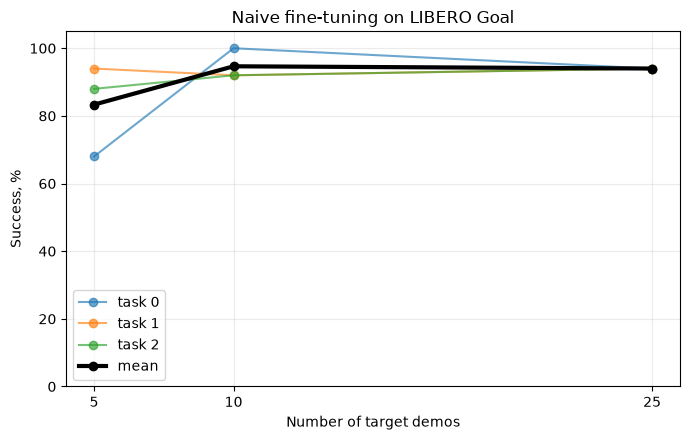

In [5]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("..")
TASKS = [0, 1, 2]
DEMOS = [5, 10, 25]
CKPT = "005000"

rows = []

for task_id in TASKS:
    for demos in DEMOS:
        run = f"smolvla_libero90_pretrained_finetune_t{task_id}_d{demos}"
        path = ROOT / "logs" / run / f"{CKPT}_libero_goal_{task_id}" / "eval_info.json"

        with open(path) as f:
            info = json.load(f)

        rows.append({
            "task_id": task_id,
            "demos": demos,
            "success_percent": info["overall"]["pc_success"],
            "n_episodes": info["overall"]["n_episodes"],
        })

df = pd.DataFrame(rows).sort_values(["task_id", "demos"])
display(df)

mean_df = (
    df.groupby("demos", as_index=False)
      .agg(mean_success_percent=("success_percent", "mean"))
)

display(mean_df)

plt.figure(figsize=(7, 4.5))

for task_id in TASKS:
    part = df[df["task_id"] == task_id]
    plt.plot(
        part["demos"],
        part["success_percent"],
        marker="o",
        linewidth=1.5,
        alpha=0.65,
        label=f"task {task_id}",
    )

plt.plot(
    mean_df["demos"],
    mean_df["mean_success_percent"],
    marker="o",
    linewidth=3,
    color="black",
    label="mean",
)

plt.xticks(DEMOS)
plt.ylim(0, 105)
plt.xlabel("Number of target demos")
plt.ylabel("Success, %")
plt.title("Naive fine-tuning on LIBERO Goal")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

Перед дальнейшими запусками ожидаю резкий рост success от 0 к 5 target demonstrations, затем насыщение примерно к 10 demonstrations. Результат на 25 demonstrations может быть на том же уровне или немного ниже из-за шума обучения и eval.

Основная причина: seen checkpoint уже обучался на LIBERO-90 и должен иметь базовые visuomotor-навыки: reaching, движение руки, взаимодействие с объектами. Поэтому небольшое число target demonstrations должно в основном донастроить модель под конкретную held-out goal-задачу и её языковую инструкцию.

# Про вторую стадию 

Так мне необходимо побить этот бейзлайн. \
Условия:
- 50 эпизодов оценки на задачу и точку
- два сида обучения

Эксперименты:

1. Файнтюн на таргет демо + немного seen demos из LIBERO-90


2. Уменьшение n_action_steps с 50 до 10 или 5 улучшит success в задачах, где ошибка возникает из-за раннего промаха, плохого подхода к объекту или неудачного grasp. Ожидаю наибольший эффект на 5 demos, меньший на 10/25 demos.

3. LoRA fine-tuning добавляет небольшое число обучаемых адаптеров поверх frozen SmolVLA. Я ожидаю, что это даст модели больше гибкости, чем naive fine-tune только action expert/state projection, но при этом будет менее рискованно, чем полный fine-tune на малом числе target demos.

## Эксперимент 1

Я проверяю, поможет ли добавление небольшого replay из LIBERO-90 при дообучении на target demos. Ожидаю, что seen replay сохранит базовые навыки из seen checkpoint и уменьшит переобучение на маленьких target-наборах, особенно при 5 demonstrations.

Взять те же target episodes, что в baseline:

task 0 d5/d10/d25\
task 1 d5/d10/d25\
task 2 d5/d10/d25\

И возьмём  10 доп эпизодов с шагом по всем эпизодам из libero_goal



In [ ]:
from pathlib import Path
import pandas as pd

name = "libero_90"
root = Path("../data") / name
episode_files = sorted((root / "meta" / "episodes").glob("**/*.parquet"))
episodes = pd.concat([pd.read_parquet(p) for p in episode_files], ignore_index=True)

print(name)
print("episodes:", len(episodes))
print("frames:", episodes["length"].sum())
print()

libero_90
episodes: 3921
frames: 569249



Так проще всего для дизайна кончно сделать один такой набор данных 10 replay + 25 task0 + 25 task1 + 25 task2 и перед запуском подавать нужные эпизоды, но как я понял все нормализации поёдут по этим всем 85 эпизодам и поэтому стоит сделать отдельные 9 небольших наборов данных.


P.S возникла проблема:

Проблема: `lerobot-edit-dataset split` падал на `data/libero_goal/.../wrist_image/.../file-000.mp4` из-за PyAV `InvalidDataError` на одном AV1-пакете. `ffmpeg` файл дочитывал, но PyAV внутри LeRobot останавливался.

Команды ремонта:

```bash
SRC=data/libero_goal/videos/observation.images.wrist_image/chunk-000/file-000.mp4

cp "$SRC" "$SRC.bak"

ffmpeg -y -err_detect ignore_err \
  -i "$SRC.bak" \
  -an -r 20 \
  -c:v libsvtav1 -pix_fmt yuv420p -crf 30 -preset 12 \
  "$SRC.fixed.mp4"

echo $?
```

Проверка через PyAV:

```bash
./.venv/bin/python -c "import av; p='data/libero_goal/videos/observation.images.wrist_image/chunk-000/file-000.mp4.fixed.mp4'; c=av.open(p); s=c.streams.video[0]; print(sum(1 for _ in c.decode(s)))"
```

Ожидаемо: `52042`.

Если проверка прошла:

```bash
mv "$SRC.fixed.mp4" "$SRC"
```

Потом заново подготовить датасет:

```bash
FORCE=1 ./scripts/task_2/prepare_goal_replay_dataset.sh 0 5
```

Важно: actions/states/metadata не менялись; был переэнкожен только один mp4 камеры `wrist_image`. Backup сохранён как `file-000.mp4.bak`.

Перед основными запусками Task 2 я сделал pilot-прогон метода на одной точке cost curve: task 0, 5 demos. Цель была не подобрать лучший результат, а проверить, не меняет ли добавление LIBERO-90 replay динамику обучения относительно naive baseline.

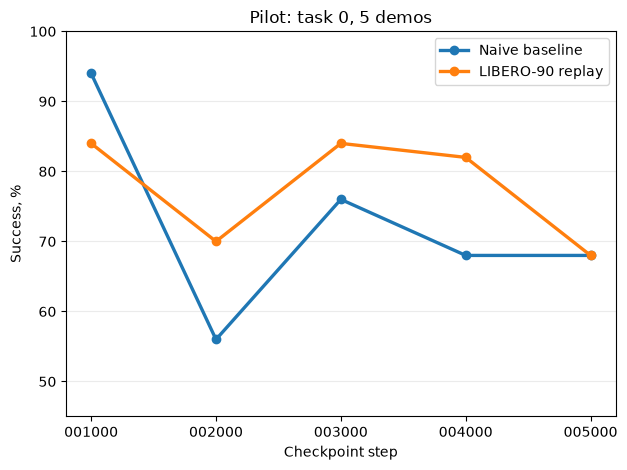

In [12]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

ROOT = Path("..").resolve()

ckpts = ["001000", "002000", "003000", "004000", "005000"]
steps = [int(x) for x in ckpts]

runs = {
    "Naive baseline": ROOT / "logs/smolvla_libero90_pretrained_finetune_t0_d5",
    "LIBERO-90 replay": ROOT / "logs/smolvla_libero90_replay_t0_d5",
}

for name, run_dir in runs.items():
    values = []
    for ckpt in ckpts:
        path = run_dir / f"{ckpt}_libero_goal_0/eval_info.json"
        data = json.loads(path.read_text())
        values.append(float(data["overall"]["pc_success"]))

    plt.plot(steps, values, marker="o", linewidth=2.4, label=name)

plt.title("Pilot: task 0, 5 demos")
plt.xlabel("Checkpoint step")
plt.ylabel("Success, %")
plt.xticks(steps, ckpts)
plt.ylim(45, 100)
plt.grid(True, axis="y", alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

По самому графику сразу бросается в глаза, что наивный baseline при `1000 steps` лучше, чем все остальные точки. Но если смотреть не на отдельный пик, а на динамику обучения, то replay выглядит лучше на промежуточных шагах.

Поэтому заранее сказать, что этот эксперимент неудачный, я не могу. Нужно попробовать его полноценно: добавить второй seed и посмотреть на результаты в целом. Я уже зафиксировал методику: для итогового сравнения буду брать `5000 ckpt` и не менять это решение задним числом. Ниже посмотрим на график `success rate`, усреднённый по задачам и seed.



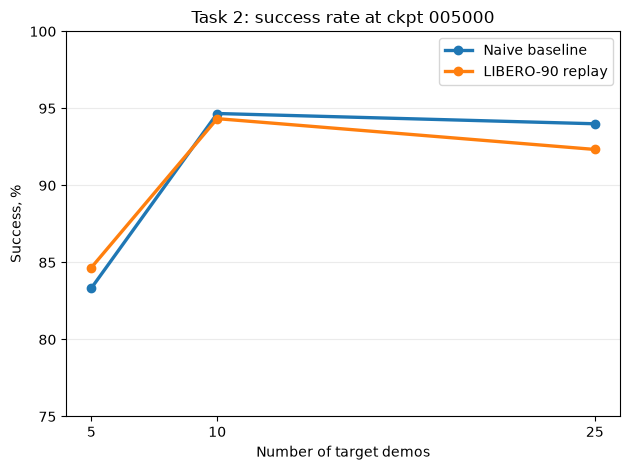

baseline: [83.33333333333333, 94.66666666666667, 94.0]
replay: [84.66666666666667, 94.33333333333333, 92.33333333333333]


In [9]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

ROOT = Path("..").resolve()
demos = [5, 10, 25]

baseline = []
replay = []

for d in demos:
    vals = []
    for t in [0, 1, 2]:
        p = ROOT / f"logs/smolvla_libero90_pretrained_finetune_t{t}_d{d}/005000_libero_goal_{t}/eval_info.json"
        vals.append(json.loads(p.read_text())["overall"]["pc_success"])
    baseline.append(sum(vals) / len(vals))

    vals = []
    for seed_suffix in ["", "_s2000"]:
        for t in [0, 1, 2]:
            p = ROOT / f"logs/smolvla_libero90_replay_t{t}_d{d}{seed_suffix}/005000_libero_goal_{t}/eval_info.json"
            vals.append(json.loads(p.read_text())["overall"]["pc_success"])
    replay.append(sum(vals) / len(vals))

plt.plot(demos, baseline, marker="o", linewidth=2.4, label="Naive baseline")
plt.plot(demos, replay, marker="o", linewidth=2.4, label="LIBERO-90 replay")

plt.title("Task 2: success rate at ckpt 005000")
plt.xlabel("Number of target demos")
plt.ylabel("Success, %")
plt.xticks(demos)
plt.ylim(75, 100)
plt.grid(True, axis="y", alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

print("baseline:", baseline)
print("replay:", replay)

Исходя из этого графика, я не могу сказать, что данный эксперимент оправдал мои ожидания.

Метод с добавлением LIBERO-90 replay дал небольшой прирост только в точке 5 demos, но на 10 demos оказался практически на уровне naive baseline, а на 25 demos уже немного проиграл. Это говорит о том, что replay действительно может немного помогать при очень малом числе целевых демонстраций, но при увеличении числа target demos он, скорее всего, начинает разбавлять целевой сигнал и мешать дообучению на конкретной задаче.

При этом эксперимент всё равно полезен: он показал, что простой replay без балансировки или увеличения веса target demos недостаточен, чтобы стабильно побить baseline.

## Эксперимент 2

Я ожидал, что уменьшение n_action_steps улучшит способность модели исправлять ошибки во время rollout. В baseline модель исполняет до 50 действий из одного предсказанного chunk, поэтому если она рано промахивается или неправильно подходит к объекту, она некоторое время продолжает старый план. Я предполагал, что более частое перепланирование с n_action_steps=10 или 5 позволит модели чаще смотреть на текущее изображение и корректировать поведение. Ожидал наибольший эффект на 5 demos, где модель хуже адаптирована к target-задаче, и меньший эффект на 10/25 demos.

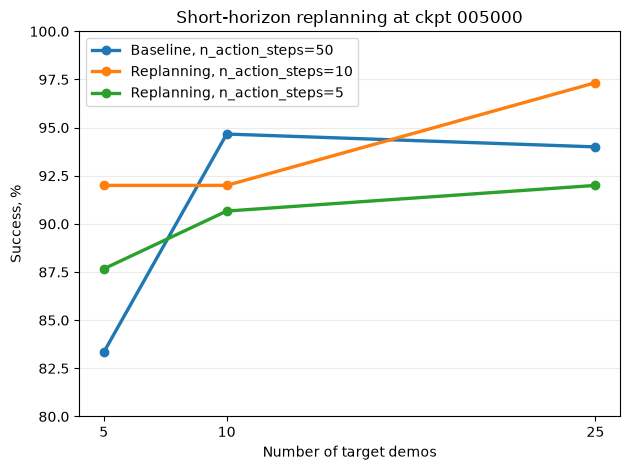

baseline: [83.33333333333333, 94.66666666666667, 94.0]
replan10: [92.0, 92.0, 97.33333333333333]
replan5: [87.66666666666667, 90.66666666666667, 92.0]


In [24]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

ROOT = Path("..").resolve()
demos = [5, 10, 25]
tasks = [0, 1, 2]
seeds = ["1000", "2000"]

def read_success(path):
    return json.loads(path.read_text())["overall"]["pc_success"]

baseline = []
replan10 = []
replan5 = []

for d in demos:
    vals = []
    for t in tasks:
        p = ROOT / f"logs/smolvla_libero90_pretrained_finetune_t{t}_d{d}/005000_libero_goal_{t}/eval_info.json"
        vals.append(read_success(p))
    baseline.append(sum(vals) / len(vals))

    vals = []
    for t in tasks:
        for seed in seeds:
            p = ROOT / f"logs/smolvla_libero90_pretrained_finetune_t{t}_d{d}/005000_libero_goal_{t}_act_steps_10_s_{seed}/eval_info.json"
            vals.append(read_success(p))
    replan10.append(sum(vals) / len(vals))

    vals = []
    for t in tasks:
        for seed in seeds:
            p = ROOT / f"logs/smolvla_libero90_pretrained_finetune_t{t}_d{d}/005000_libero_goal_{t}_act_steps_5_s_{seed}/eval_info.json"
            vals.append(read_success(p))
    replan5.append(sum(vals) / len(vals))

plt.plot(demos, baseline, marker="o", linewidth=2.4, label="Baseline, n_action_steps=50")
plt.plot(demos, replan10, marker="o", linewidth=2.4, label="Replanning, n_action_steps=10")
plt.plot(demos, replan5, marker="o", linewidth=2.4, label="Replanning, n_action_steps=5")

plt.title("Short-horizon replanning at ckpt 005000")
plt.xlabel("Number of target demos")
plt.ylabel("Success, %")
plt.xticks(demos)
plt.ylim(80, 100)
plt.grid(True, axis="y", alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

print("baseline:", baseline)
print("replan10:", replan10)
print("replan5:", replan5)

Результаты частично подтвердили гипотезу. Режим n_action_steps=10 заметно улучшил средний success на 5 demos: с 83.3% до 92.0%, а также улучшил 25 demos: с 94.0% до 97.3%. Однако на 10 demos success снизился с 94.7% до 92.0%. Более агрессивное перепланирование n_action_steps=5 оказалось хуже: оно дало небольшой прирост на 5 demos, но ухудшило 10 и 25 demos.

Это говорит о том, что слишком длинный action chunk действительно может мешать исправлению ранних ошибок, но слишком частое перепланирование тоже вредно: политика становится менее плавной и может разрушать хороший локальный план.

## Эксперимент 3

Я ожидаю, что LoRA даст более устойчивое дообучение на малом числе демонстраций, потому что будет менять только небольшое число параметров и тем самым меньше переобучаться на 5/10/25 target demos. Также я ожидаю, что эффект будет сильнее на малых бюджетах, где полный naive fine-tuning может быть слишком агрессивным.

,task_id,demos,seed,baseline,lora,delta
0,0,5,1000,68.0,80.0,12.0
1,0,5,2000,68.0,92.0,24.0
2,1,5,1000,94.0,72.0,-22.0
3,1,5,2000,94.0,68.0,-26.0
4,2,5,1000,88.0,88.0,0.0
5,2,5,2000,88.0,84.0,-4.0
6,0,10,1000,100.0,80.0,-20.0
7,0,10,2000,100.0,70.0,-30.0
8,1,10,1000,92.0,84.0,-8.0
9,1,10,2000,92.0,78.0,-14.0


,demos,baseline_mean,lora_mean,lora_std,n,delta_mean
0,5,83.333333,80.666667,9.266427,6,-2.666667
1,10,94.666667,81.333333,7.339391,6,-13.333333
2,25,94.000000,78.000000,7.694154,6,-16.000000


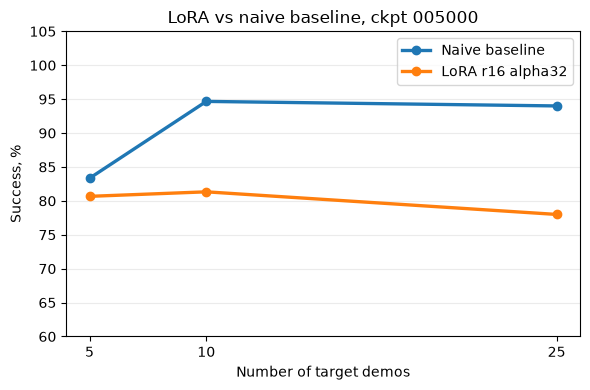

In [27]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("..").resolve()
CKPT = "005000"

tasks = [0, 1, 2]
demos_list = [5, 10, 25]
seeds = [1000, 2000]

def read_success(path):
    if not path.exists():
        return None
    return json.loads(path.read_text())["overall"]["pc_success"]

rows = []

for demos in demos_list:
    for task_id in tasks:
        baseline_path = ROOT / f"logs/smolvla_libero90_pretrained_finetune_t{task_id}_d{demos}/{CKPT}_libero_goal_{task_id}/eval_info.json"
        baseline = read_success(baseline_path)

        for seed in seeds:
            lora_path = ROOT / f"logs/smolvla_libero90_pretrained_finetune_t{task_id}_d{demos}_lora_r16_alpha32_s_{seed}/{CKPT}_libero_goal_{task_id}/eval_info.json"
            lora = read_success(lora_path)

            rows.append({
                "task_id": task_id,
                "demos": demos,
                "seed": seed,
                "baseline": baseline,
                "lora": lora,
                "delta": None if baseline is None or lora is None else lora - baseline,
            })

df = pd.DataFrame(rows)
display(df)

summary = (
    df.groupby("demos")
      .agg(
          baseline_mean=("baseline", "mean"),
          lora_mean=("lora", "mean"),
          lora_std=("lora", "std"),
          n=("lora", "count"),
      )
      .reset_index()
)

summary["delta_mean"] = summary["lora_mean"] - summary["baseline_mean"]
display(summary)

plt.figure(figsize=(6, 4))
plt.plot(summary["demos"], summary["baseline_mean"], marker="o", linewidth=2.4, label="Naive baseline")
plt.plot(summary["demos"], summary["lora_mean"], marker="o", linewidth=2.4, label="LoRA r16 alpha32")

plt.title("LoRA vs naive baseline, ckpt 005000")
plt.xlabel("Number of target demos")
plt.ylabel("Success, %")
plt.xticks(demos_list)
plt.ylim(60, 105)
plt.grid(True, axis="y", alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


На практике LoRA с `r=16, alpha=32` не улучшила общий baseline. Средний success получился ниже naive fine-tuning: `80.7%` против `83.3%` на 5 demos, `81.3%` против `94.7%` на 10 demos и `78.0%` против `94.0%` на 25 demos. При этом LoRA всё же дала локальное улучшение на самой слабой точке naive baseline: для `task 0, 5 demos` результат вырос с `68%` до `86%`.

Итог: LoRA оказалась полезной как более лёгкая и параметрически экономная адаптация, но в выбранной конфигурации не побила baseline по всей cost curve. Вероятно, ограничение обучаемых параметров оказалось слишком сильным для точной моторной адаптации, либо нужны отдельные настройки `lr`, `r`, `alpha` и target modules.

# Разбор фейлов
